## <span style='text-decoration: double underline;color:rgb(10,110,217)'>**Results Model 011**</span>

**Loss function configuration:**

$\lambda_{init} = 0$  
$\lambda_{phys} = 1$  
$\lambda_{bin} = 1$

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('../')

In [3]:
import utils.evaluation_tools as eval_tools

delta = 1 
shape = (25,25)
model_name = 'DiffGoLFinReg'
parent_folder = '../Data'
seed2plot = 221
seeds = [221, 502, 700, 1204, 3340, 4501, 6054, 6621,8421, 15678, 19302, 38475, 77293, 91827, 99100]  

threshold = 0.5
figsize = (12,9)
subplots_grid = (3,3)
suptitle = 'DiffGoLFinReg Model'
th_ranges = [(0.45, 0.55), (0.40, 0.60), (0.35, 0.65)]

train_history_paths = eval_tools.get_paths_results('train_history.csv', parent_folder, seeds, shape, delta, model_name)
predictions_paths = eval_tools.get_paths_results('predictions.csv', parent_folder, seeds, shape, delta, model_name)
test_results_paths = eval_tools.get_paths_results('test_results.csv', parent_folder, seeds, shape, delta, model_name)
test_data = eval_tools.get_paths_results('test.npz', parent_folder, seeds, shape, delta, model_name)

### <span style='color:rgb(10,110,217)'><u>**Train Results**</u></span>

--- Metrics computed during execution ---
loss: 0.2169 ± 0.0061
val_loss: 0.2182 ± 0.0056


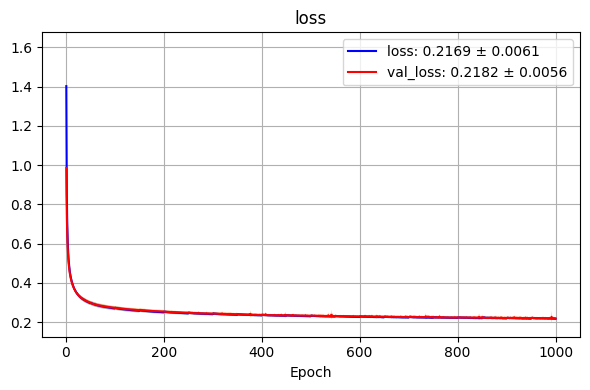

In [4]:
cols2omit = 1
num_rows = 1
eval_tools.display_results(train_history_paths, 'val_', cols2omit, num_rows, True, True)

### <span style='color:rgb(10,110,217)'><u>**Test Results**</u></span>

In [5]:
# Test:
eval_tools.display_results(test_results_paths, '_fin', display_plot=False)

--- Metrics computed during execution ---
Accuracy_init: 0.4231 ± 0.1594
Accuracy_fin: 0.9546 ± 0.0023
Recall_init: 0.2687 ± 0.0394
Recall_fin: 0.8707 ± 0.0079
Specificity_init: 0.4634 ± 0.2066
Specificity_fin: 0.9755 ± 0.0013
Precision_init: 0.1370 ± 0.0624
Precision_fin: 0.8986 ± 0.0054
F1Score_init: 0.1711 ± 0.0422
F1Score_fin: 0.8844 ± 0.0061


--- Results Initial States (15 seeds) ---
Density (true): 20.71% ± 8.76%
Density (pred): 48.50% ± 12.46%
Error/seed:     28.04% ± 17.29%
Max value predicted: 1.0000
HUC% (0.45, 0.55): 0.79% ± 0.05%
HUC% (0.4, 0.6): 1.63% ± 0.11%
HUC% (0.35, 0.65): 2.57% ± 0.17%
Fuzziness Index: 0.1260 ± 0.0663
MSE (prob):0.5473 ± 0.2011
MSE (bin):0.5769 ± 0.1958
MSE (all-zero): 0.2071 ± 0.0876
Wasserstein (EMD): 3.4028 ± 0.8362


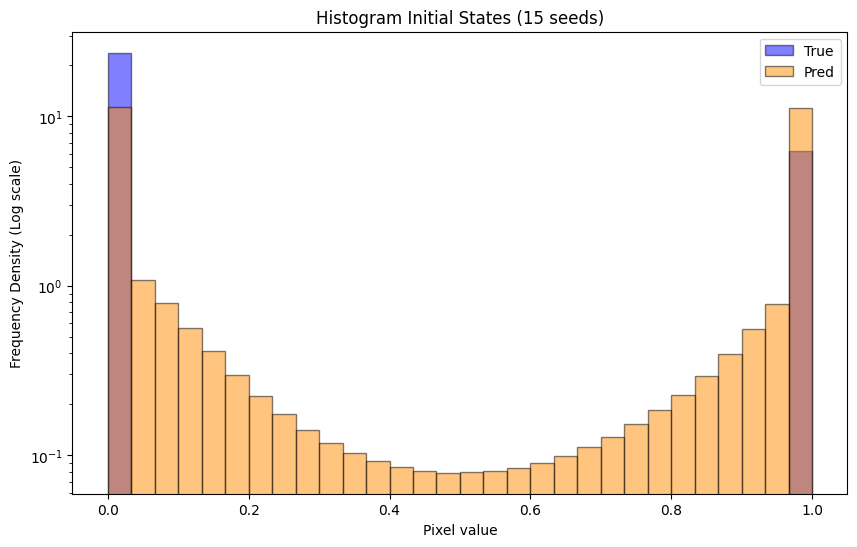

In [6]:
eval_tools.compute_metrics(predictions_paths, test_data,shape,'init', th_ranges, threshold, colors=['blue', 'darkorange'])

--- Results Final States (15 seeds) ---
Density (true): 19.93% ± 8.62%
Density (pred): 19.01% ± 7.64%
Error/seed:     0.93% ± 0.19%
Max value predicted: 1.0000
HUC% (0.45, 0.55): 1.52% ± 0.05%
HUC% (0.4, 0.6): 3.07% ± 0.09%
HUC% (0.35, 0.65): 4.70% ± 0.13%
Fuzziness Index: 0.1412 ± 0.0744
MSE (prob):0.0326 ± 0.0216
MSE (bin):0.0454 ± 0.0319
MSE (all-zero): 0.1993 ± 0.0862
Wasserstein (EMD): 1.4312 ± 0.0246


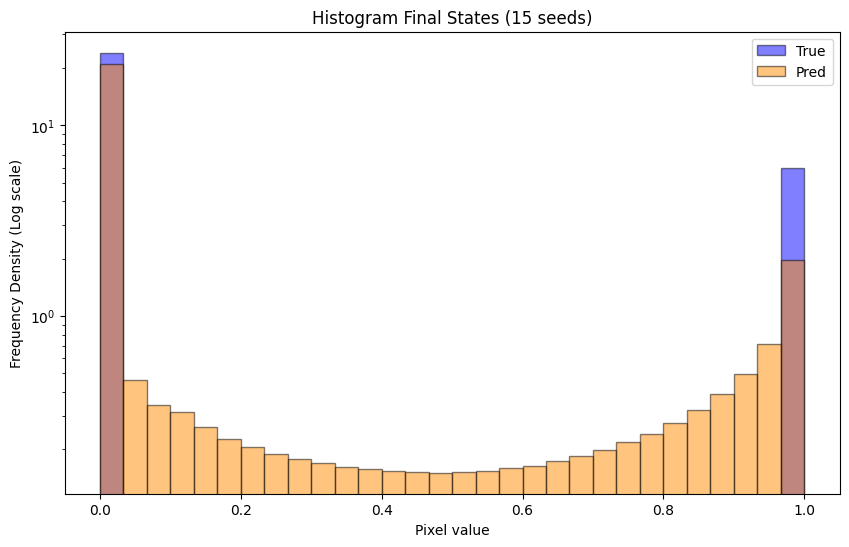

In [7]:
eval_tools.compute_metrics(predictions_paths, test_data,shape,'fin', th_ranges, threshold, colors=['blue', 'darkorange'])

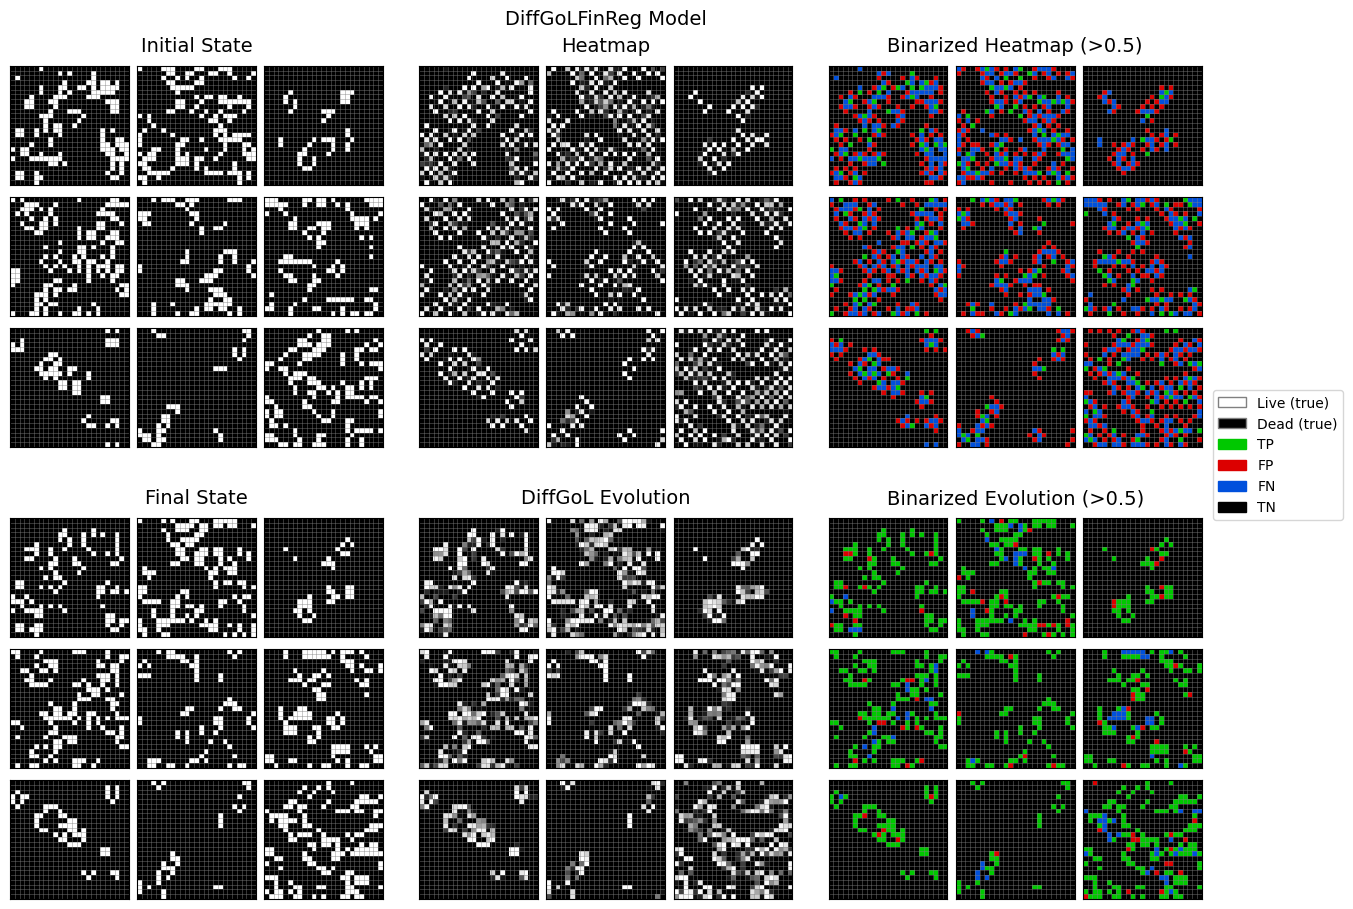

In [8]:
file_test = test_data[seed2plot]
file_pred = predictions_paths[seed2plot]
titles = ['Initial State', 'Heatmap', f'Binarized Heatmap (>{threshold})', 
          'Final State', 'DiffGoL Evolution', f'Binarized Evolution (>{threshold})']
eval_tools.display_states(file_pred, file_test, shape, threshold, titles, subplots_grid, suptitle, figsize, random=False)